Counties: 23 | highlighted: 5 -> ['Teton', 'Lincoln', 'Sublette', 'Albany', 'Carbon']
Missing cells (left blank): 27 of 230
Saved gap_heatmap.png and gap_heatmap.pdf


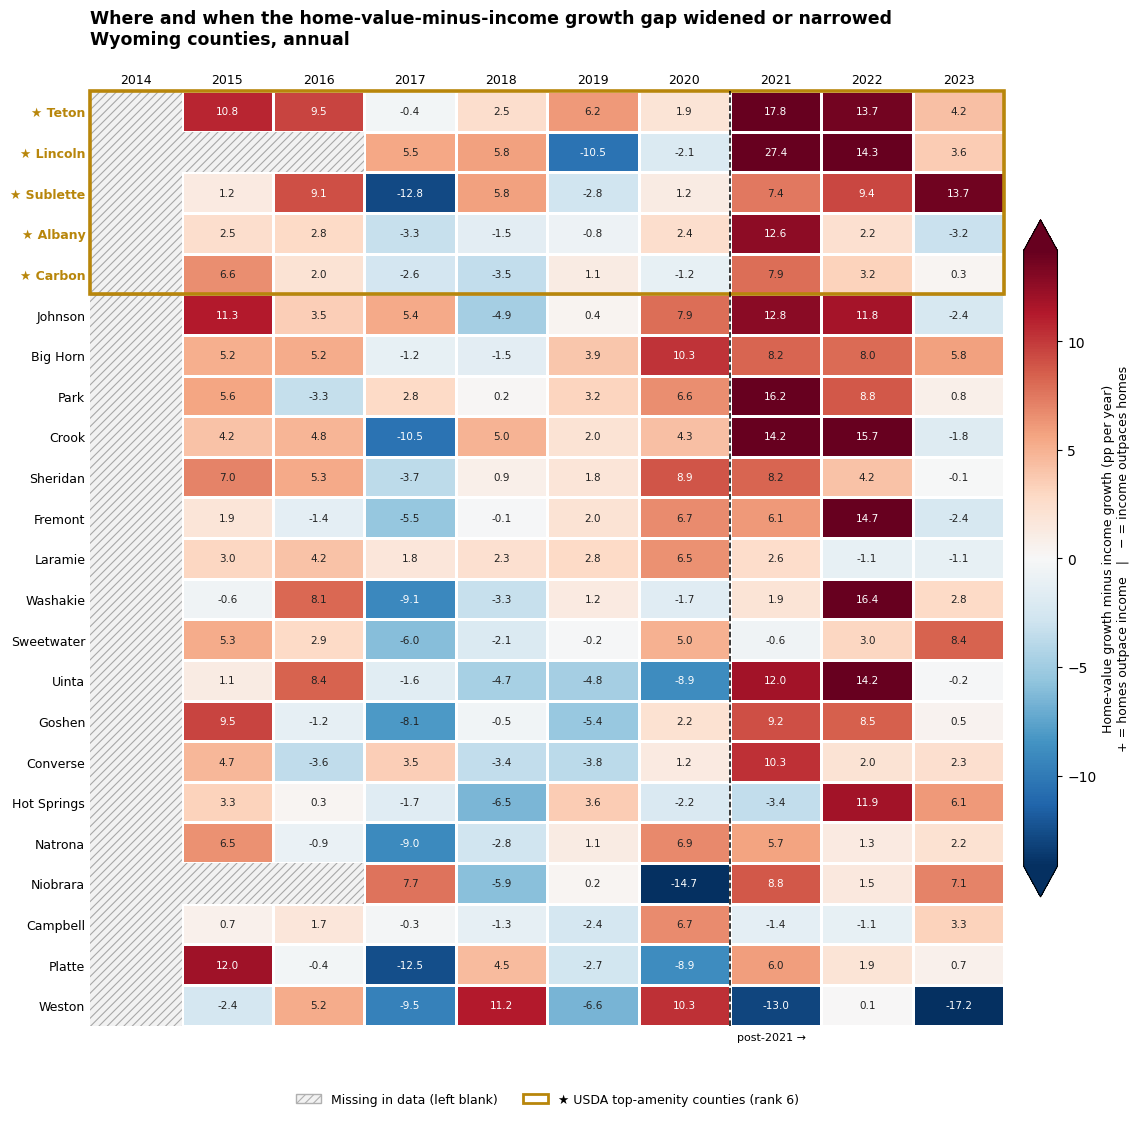

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle, Patch

is_jupyter = any("ipykernel" in arg for arg in sys.argv) or (len(sys.argv) > 1 and sys.argv[1] == "-f")

CSV_PATH = (
    sys.argv[1]
    if len(sys.argv) > 1 and not is_jupyter
    else "https://raw.githubusercontent.com/ali-findra/ProjectCowboy/refs/heads/main/IMPROVED%20DATABASE%20with%20usda_rankings.csv"
)
OUT_PREFIX = (
    sys.argv[2]
    if len(sys.argv) > 2 and not is_jupyter
    else "gap_heatmap"
)

OUTCOME = "decoupling_pp"
POST_YEAR = 2021

HIGHLIGHT_MODE = "top5"

SORT_WITHIN_GROUP = "mean_gap"
ANNOTATE_VALUES = True
CLIP_PCT = 95

HIGHLIGHT_COLOR = "#B8860B"
def load_panel(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    recomputed = df["zhvi_yoy_pct"] - df["income_yoy_pct"]
    assert np.allclose(recomputed.dropna(), df.loc[recomputed.notna(), OUTCOME], atol=1e-6), \
        f"{OUTCOME} does not equal zhvi_yoy_pct - income_yoy_pct"

    if HIGHLIGHT_MODE == "top5":
        flag, label = "high_amenity_usda", "USDA top-amenity counties (rank 6)"
    elif HIGHLIGHT_MODE == "rank5+":
        flag, label = "usda_rank5plus_group", "USDA rank 5+ counties"
    else:
        raise ValueError("HIGHLIGHT_MODE must be 'top5' or 'rank5+'")

    df["highlight"] = df.groupby("county")[flag].transform("max").astype(bool)
    df.attrs["highlight_label"] = label
    return df


def build_matrix(df: pd.DataFrame):
    """Return (matrix DataFrame counties x years, ordered county list, n_highlighted)."""
    mat = df.pivot(index="county", columns="year", values=OUTCOME)
    flags = df.groupby("county")["highlight"].first()

    def order(counties):
        if SORT_WITHIN_GROUP == "mean_gap":
            return mat.loc[counties].mean(axis=1).sort_values(ascending=False).index.tolist()
        return sorted(counties)

    hi = order(flags[flags].index)
    lo = order(flags[~flags].index)
    mat = mat.loc[hi + lo]
    return mat, len(hi)


def plot_heatmap(mat: pd.DataFrame, n_hi: int, highlight_label: str):
    counties = mat.index.tolist()
    years = mat.columns.tolist()
    n_rows, n_cols = mat.shape
    values = mat.to_numpy(dtype=float)
    missing = np.isnan(values)

    vmax = np.nanpercentile(np.abs(values), CLIP_PCT)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap = plt.get_cmap("RdBu_r")

    plt.rcParams["hatch.color"] = "#B0B0B0"
    plt.rcParams["hatch.linewidth"] = 0.8

    fig_h = max(7, 0.36 * n_rows + 3)
    fig, ax = plt.subplots(figsize=(11.5, fig_h))

    x_edges = np.arange(n_cols + 1)
    y_edges = np.arange(n_rows + 1)

    mesh = ax.pcolormesh(x_edges, y_edges, np.ma.masked_invalid(values),
                         cmap=cmap, norm=norm, edgecolors="white", linewidth=0.8)

    for i, j in zip(*np.where(missing)):
        ax.add_patch(Rectangle((j, i), 1, 1, facecolor="#F2F2F2", edgecolor="#A8A8A8",
                               hatch="////", linewidth=0, zorder=2))

    if ANNOTATE_VALUES:
        for i in range(n_rows):
            for j in range(n_cols):
                v = values[i, j]
                if np.isnan(v):
                    continue
                strong = abs(v) > 0.6 * vmax
                ax.text(j + 0.5, i + 0.5, f"{v:.1f}", ha="center", va="center",
                        fontsize=7.5, color="white" if strong else "#222222")

    ax.set_xlim(0, n_cols)
    ax.set_ylim(n_rows, 0)
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(years, fontsize=9)
    ax.xaxis.tick_top()
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels(counties, fontsize=9)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

    ax.set_yticklabels([("★ " + c) if i < n_hi else c for i, c in enumerate(counties)], fontsize=9)
    for i, tick in enumerate(ax.get_yticklabels()):
        if i < n_hi:
            tick.set_fontweight("bold")
            tick.set_color(HIGHLIGHT_COLOR)

    ax.add_patch(Rectangle((0, 0), n_cols, n_hi, fill=False, edgecolor=HIGHLIGHT_COLOR,
                           linewidth=2.6, clip_on=False, zorder=5))
    if n_hi < n_rows:
        ax.axhline(n_hi, color="black", linewidth=1.0, zorder=4)

    if POST_YEAR in years:
        xp = years.index(POST_YEAR)
        ax.axvline(xp, color="black", linestyle="--", linewidth=1.1, zorder=6)
        ax.text(xp + 0.08, n_rows + 0.15, f"post-{POST_YEAR} →", fontsize=8, va="top", ha="left")

    cbar = fig.colorbar(mesh, ax=ax, fraction=0.035, pad=0.02, extend="both")
    cbar.set_label("Home-value growth minus income growth (pp per year)\n+ = homes outpace income   |   − = income outpaces homes", fontsize=9)

    handles = [
        Patch(facecolor="#F2F2F2", edgecolor="#B0B0B0", hatch="////", label="Missing in data (left blank)"),
        Patch(facecolor="none", edgecolor=HIGHLIGHT_COLOR, linewidth=2, label=f"★ {highlight_label}"),
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.04 if POST_YEAR not in years else -0.06),
              ncol=2, frameon=False, fontsize=9)

    ax.set_title("Where and when the home-value-minus-income growth gap widened or narrowed\n"
                 "Wyoming counties, annual",
                 fontsize=12.5, fontweight="bold", pad=34, loc="left")

    fig.tight_layout()
    return fig


def main():
    df = load_panel(CSV_PATH)
    mat, n_hi = build_matrix(df)

    print(f"Counties: {len(mat)} | highlighted: {n_hi} -> {mat.index[:n_hi].tolist()}")
    print(f"Missing cells (left blank): {int(mat.isna().sum().sum())} of {mat.size}")

    fig = plot_heatmap(mat, n_hi, df.attrs["highlight_label"])
    fig.savefig(f"{OUT_PREFIX}.png", dpi=200, bbox_inches="tight")
    fig.savefig(f"{OUT_PREFIX}.pdf", bbox_inches="tight")
    print(f"Saved {OUT_PREFIX}.png and {OUT_PREFIX}.pdf")


if __name__ == "__main__":
    main()